In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv(r"D:\New folder (2)\Documents\New folder\superstore.csv",encoding="latin-1")

print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [21]:
print(df.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [23]:
#checking if there any values exists in data

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [35]:
#Checking unique values


print(df['Category'].unique())
print(df['Region'].unique())

['Furniture' 'Office Supplies' 'Technology']
['South' 'West' 'Central' 'East']


In [31]:
#Converting Date for Timely Analysis

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [33]:
#Extracting Year and Month from Order Date

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

**“How is the business performing over time?”**

In [40]:
#Total Revenue

#Insight : Total Businsess Revenue

df['Sales'].sum()

2297200.8603000003

In [43]:
#Revenue By Year

#Insight : Which year performed best

df.groupby('Year')['Sales'].sum()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [45]:
#Revenue By Month

#Insight : Which months are strong/weak

df.groupby('Month')['Sales'].sum().sort_index()

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

In [51]:
#Top Products

#Top categories

df.groupby('Category')['Sales'].sum().sort_index(ascending = False)

Category
Technology         836154.0330
Office Supplies    719047.0320
Furniture          741999.7953
Name: Sales, dtype: float64

In [53]:
#Top Sub-categories

df.groupby('Sub-Category')['Sales'].sum().sort_index(ascending = False)

Sub-Category
Tables         206965.5320
Supplies        46673.5380
Storage        223843.6080
Phones         330007.0540
Paper           78479.2060
Machines       189238.6310
Labels          12486.3120
Furnishings     91705.1640
Fasteners        3024.2800
Envelopes       16476.4020
Copiers        149528.0300
Chairs         328449.1030
Bookcases      114879.9963
Binders        203412.7330
Art             27118.7920
Appliances     107532.1610
Accessories    167380.3180
Name: Sales, dtype: float64

In [57]:
#Profit Analysis

df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

#### Insights We Observed

- **Total Revenue - 2297200.8603000003**
- **Best Year - 2017**
- **Best Category - Technology**
- **Best Sub-Category - Phones**


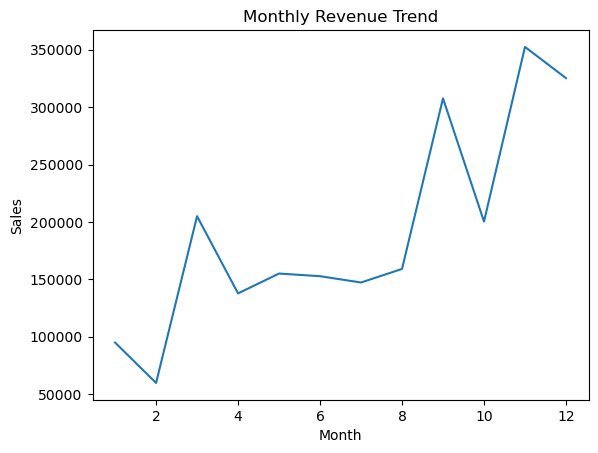

In [79]:
# Revenue By Month (Line Chart)

monthly_sales = df.groupby('Month')['Sales'].sum().sort_index()

monthly_sales.plot(kind = 'line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

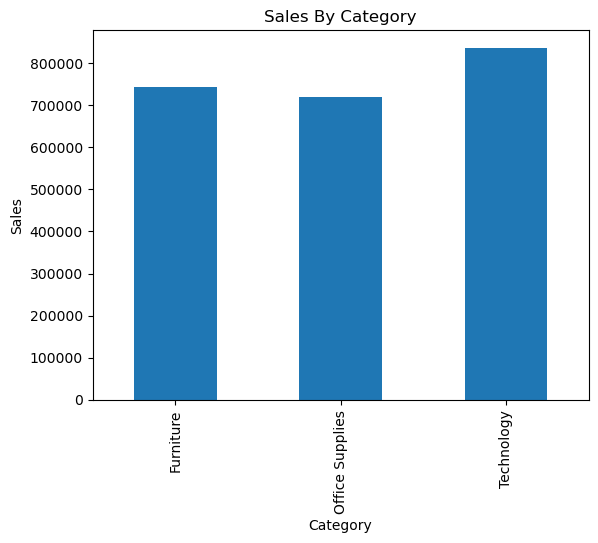

In [83]:
#Sales By Category(Bar Chart)

category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')
plt.title('Sales By Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

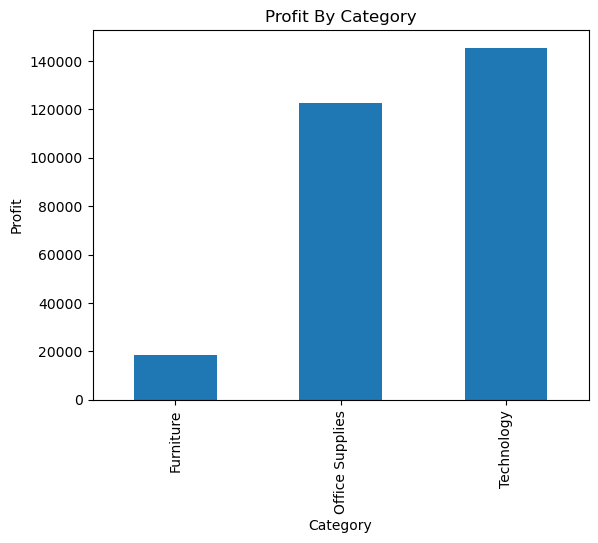

In [85]:
#Profit By Category

profit_category = df.groupby('Category')['Profit'].sum()

profit_category.plot(kind='bar')
plt.title('Profit By Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()